In [2]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

In [3]:

segyfile = 'BaseCH172_OVSP_StackRaw_Data.segy'
with segyio.open(segyfile, "r") as f:
    registro=np.array(f.trace).T
    # Carga las trazas en una matriz numpy
    trazas = np.array([f.trace[i] for i in range(f.tracecount)])






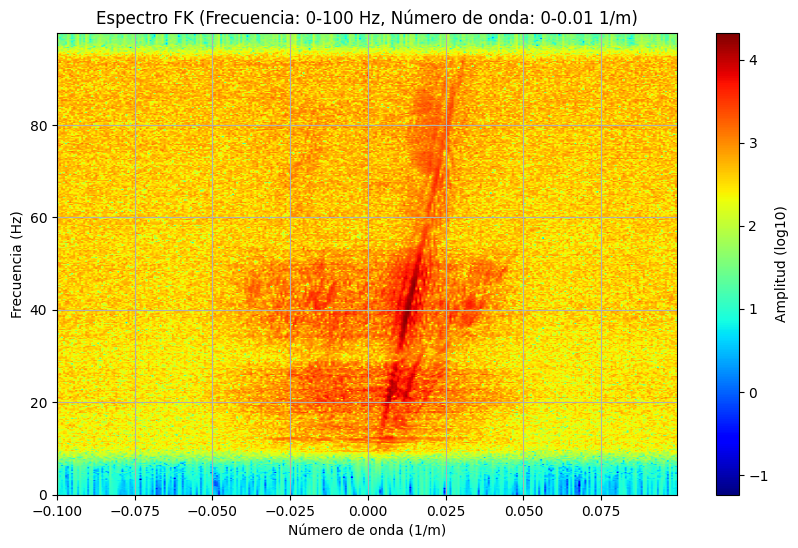

In [4]:
dt = 0.001  # Intervalo temporal en segundos (1 ms)
dx = 5 #Intervalo espacial 5m 
# Calcula la transformada de Fourier 2D
#Aqui calcula la transformada de Fourier 2D haciendo primero en el eje t y después en el eje x
#En teoria p
fk_transform = np.fft.fft(trazas.T,axis=0)
fk_transform = np.fft.ifft(fk_transform,axis=1)
# Reordena la transformada de Fourier en el eje x (k) para que los números de onda positivos queden a la izquierda 
fk_transform=np.fft.fftshift(fk_transform, axes=(1,))
# Magnitud del espectro
magnitude = np.abs(fk_transform)
magnitude_log =np.log10(magnitude + 1e-12)

nt, nx = trazas.T.shape
freqs = np.fft.fftfreq(nt, dt)  # Frecuencias (Hz)
wavenumbers = np.fft.fftfreq(nx, dx)  # Números de onda (1/m)
wavenumbers=np.fft.fftshift(wavenumbers)
# Filtrar frecuencias y números de onda positivos
freqs_positive = freqs[freqs >= 0]  # Filtrar frecuencias positivas
###wavenumbers_positive = wavenumbers[(wavenumbers >= 0) ]  # Filtrar números de onda hasta 0.11

# Seleccionar magnitudes correspondientes
fk_magnitude_log = magnitude_log[:len(freqs_positive),:]

# Limitar frecuencias a 100 Hz
freq_limit = freqs_positive[freqs_positive <= 100]
fk_magnitude_log = fk_magnitude_log[:len(freq_limit), :]

# Graficar el espectro FK acotado (amplitud logarítmica)
plt.figure(figsize=(10, 6))
extent = [wavenumbers.min(), wavenumbers.max(), freq_limit.min(), freq_limit.max()]
plt.imshow(fk_magnitude_log, aspect='auto', extent=extent, origin='lower', cmap='jet')
plt.colorbar(label='Amplitud (log10)')
plt.xlabel('Número de onda (1/m)')
plt.ylabel('Frecuencia (Hz)')
plt.title('Espectro FK (Frecuencia: 0-100 Hz, Número de onda: 0-0.01 1/m)')
plt.grid()
plt.show()

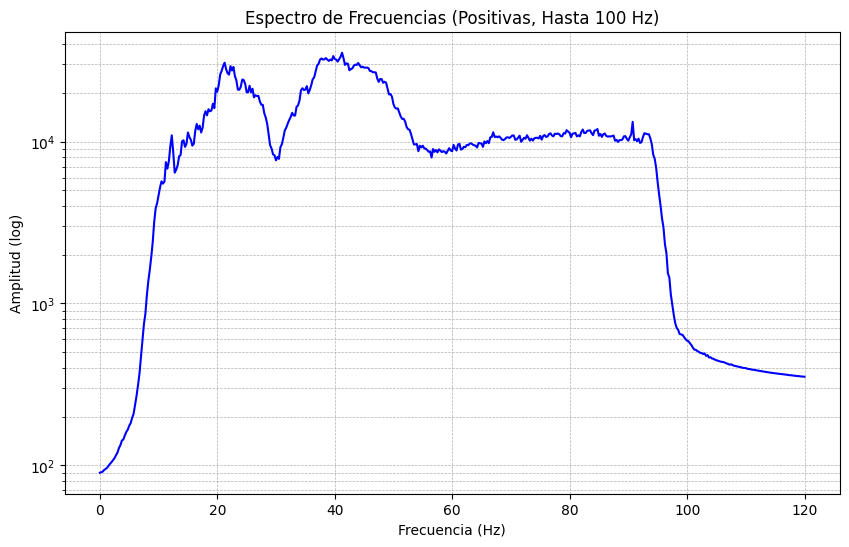

In [5]:
# Transformada de Fourier 1D (eje temporal para cada traza)
freq_transform = np.fft.fft(trazas.T, axis=0)

# Magnitud promedio del espectro
magnitude = np.abs(freq_transform).mean(axis=1)  # Promedio sobre todas las trazas

# Escala de frecuencias
nt = trazas.T.shape[0]
freqs = np.fft.fftfreq(nt, dt)  # Frecuencias (Hz)

# Filtrar frecuencias positivas hasta 100 Hz
positive_freqs = freqs[(freqs >= 0) & (freqs <= 120)]
positive_magnitude = magnitude[(freqs >= 0) & (freqs <= 120)]

# Graficar el espectro de frecuencias positivas (limitado a 100 Hz)
plt.figure(figsize=(10, 6))
plt.plot(positive_freqs, positive_magnitude, color='blue')
plt.yscale('log')  # Escala logarítmica en el eje Y
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (log)')
plt.title('Espectro de Frecuencias (Positivas, Hasta 100 Hz)')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()


## Filtros pasa banda

In [6]:
def generate_signal(time,low_freq,high_freq,sampling_rate=1000):
    t=np.linspace(0,time,int(time*sampling_rate))
    signal=np.sin(2*np.pi*low_freq*t)+0.5*np.sin(2*np.pi*high_freq*t)
    return t, signal

In [7]:
def low_pass_filter(signal,cutoff,sampling_rate=1000):
    fft_signal=np.fft.fft(signal)
    frequencies=np.fft.fftfreq(len(signal),1/sampling_rate)
    filtered_signal=np.fft.ifft(fft_signal*(np.abs(frequencies)<=cutoff)).real
    return filtered_signal

In [8]:
time=5
low_freq=5
high_freq=50
cutoff=10
t, signal=generate_signal(time,low_freq,high_freq)
filtered_signal=low_pass_filter(signal,cutoff)

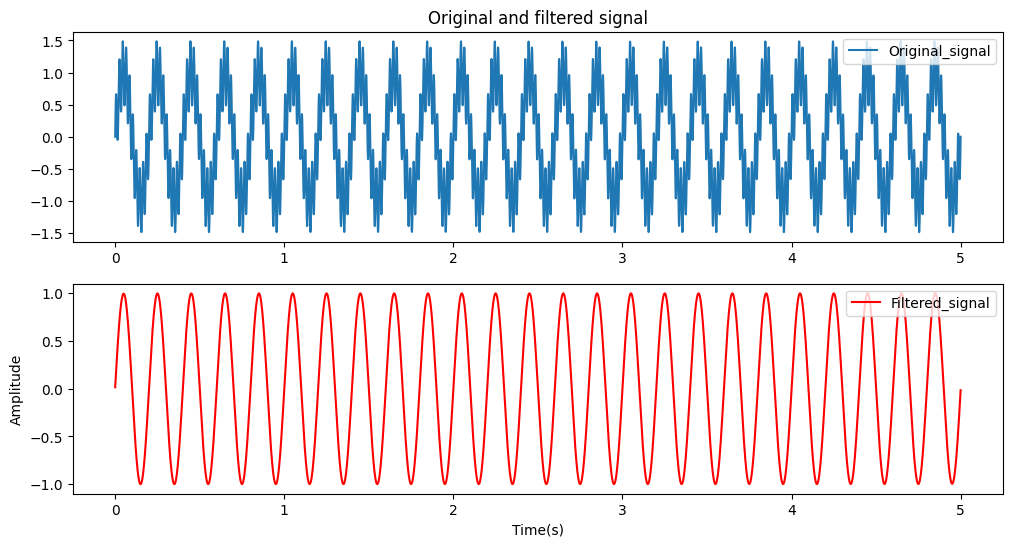

In [9]:
plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(t,signal,label="Original_signal")
plt.legend(loc="upper right")
plt.title("Original and filtered signal")
plt.subplot(2,1,2)
plt.plot(t,filtered_signal,label="Filtered_signal",color="red")
plt.legend(loc="upper right")
plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.show()


In [10]:
from scipy.signal import butter,lfilter,freqz


In [11]:
def butter_highpass(cutoff,fs,order=5):
    nyq=0.5*fs
    normal_cutoff=cutoff/nyq
    b,a=butter(order,normal_cutoff,btype="high",analog=False)
    return b,a


In [12]:
def butter_highpass_filter(data,cutoff,fs,order=5):
    b,a =butter_highpass(cutoff,fs,order=order)
    y=lfilter(b,a,data)
    return y
    
    

In [13]:
fs=5000
t=np.linspace(0,1,fs)
sig=np.sin(2*np.pi*10*t)+np.sin(2*np.pi*100*t)+np.sin(2*np.pi*1000*t)

In [14]:
cutoff=150.0
filtered_signal=butter_highpass_filter(sig,cutoff,fs,order=6)

In [15]:
filtered_signal

array([ 0.        ,  0.7561503 ,  0.04744049, ..., -0.89315736,
       -0.6615043 ,  0.5154371 ])

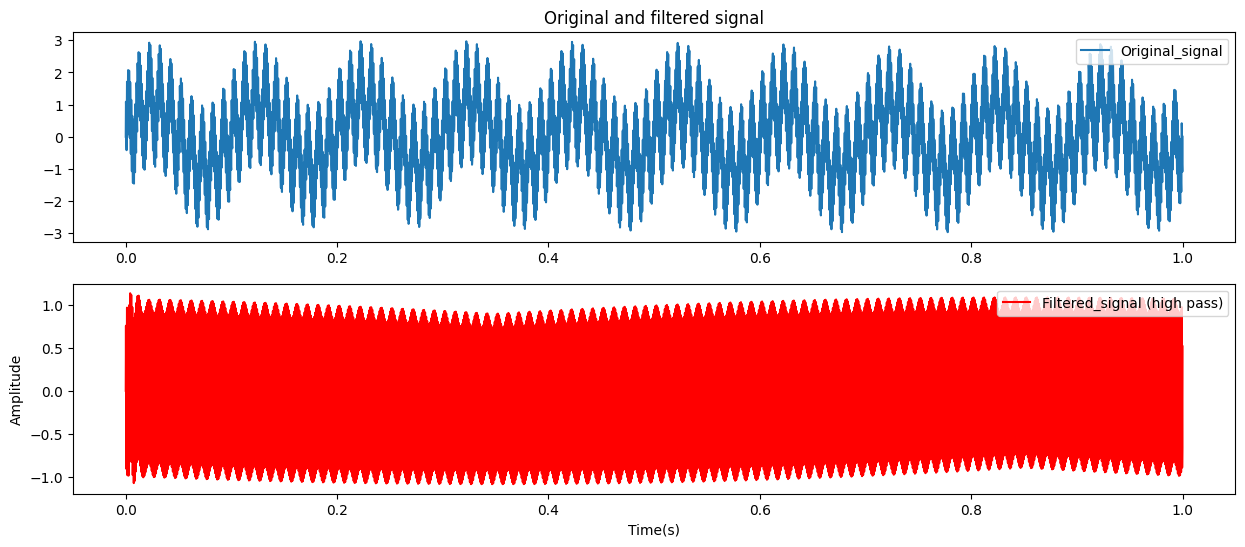

In [16]:
plt.figure(figsize=(15,6))
plt.subplot(2,1,1)
plt.plot(t,sig,label="Original_signal")
plt.legend(loc="upper right")
plt.title("Original and filtered signal")
plt.subplot(2,1,2)
plt.plot(t,filtered_signal,label="Filtered_signal (high pass)",color="red")
plt.legend(loc="upper right")
plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.show()

In [17]:
prueba=trazas[0]


In [18]:
def low_pass_filter(signal,cutoff,sampling_rate=1000):
    fft_signal=np.fft.fft(signal)
    frequencies=np.fft.fftfreq(len(signal),1/sampling_rate)
    filtered_signal=np.fft.ifft(fft_signal*(np.abs(frequencies)<=cutoff)).real
    return filtered_signal

In [19]:
prueba_20=low_pass_filter(prueba,20,4001)

In [20]:
prueba.shape

(4001,)

In [21]:
trazas.shape

(308, 4001)

In [22]:
trazas[0].shape

(4001,)

In [23]:
trazas_filtradas = np.empty((301, 4001))

In [24]:
trazas_filtradas.shape

(301, 4001)

In [51]:
def low_pass_filter(signal, cutoff, sampling_rate=1000):
    fft_signal = np.fft.fft(signal)
    frequencies = np.fft.fftfreq(len(signal), 1/sampling_rate)
    filtered_signal = np.fft.ifft(fft_signal * (np.abs(frequencies) <= cutoff)).real
    return filtered_signal

# Asegúrate que trazas tiene forma (308, 4001)
trazas_filtradas = np.empty((308, 4001))

for i in range(308):
    # trazas[i] será de forma (4001,) si trazas es (308, 4001)
    trazas_filtradas[i] = low_pass_filter(trazas[i], cutoff=20, sampling_rate=1000)


    


In [52]:
trazas_filtradas

array([[ 4.12228779e+00,  4.42736380e+00,  4.69759595e+00, ...,
         3.04717117e+00,  3.42716639e+00,  3.78722134e+00],
       [ 1.72724625e+00,  2.10340474e+00,  2.44711981e+00, ...,
         5.12068303e-01,  9.20603528e-01,  1.32933228e+00],
       [ 1.35128534e+01,  1.40417153e+01,  1.44752386e+01, ...,
         1.14700012e+01,  1.22147762e+01,  1.28998909e+01],
       ...,
       [ 1.43574440e+00,  1.63388767e+00,  1.47448524e+00, ...,
        -1.25102665e+00, -1.82704252e-02,  8.82200350e-01],
       [-2.94910976e+01, -3.35632263e+01, -3.75651800e+01, ...,
        -1.74137146e+01, -2.13620973e+01, -2.54056037e+01],
       [-1.87491802e+01, -1.98190181e+01, -2.10541077e+01, ...,
        -1.62009006e+01, -1.69756074e+01, -1.78128652e+01]])

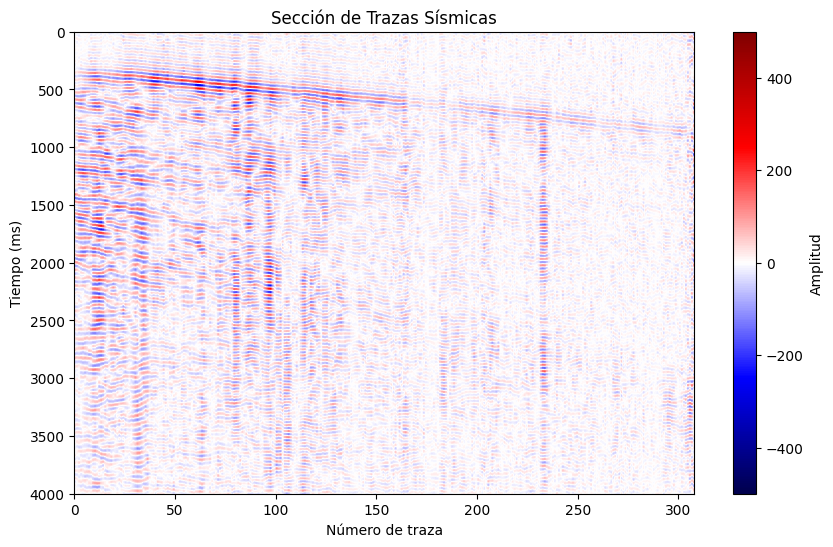

In [53]:
# Configuración para graficar las trazas sísmicas
clip = 5e+2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(trazas_filtradas.T, aspect='auto', cmap='seismic', extent=[0, 308, 4000, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

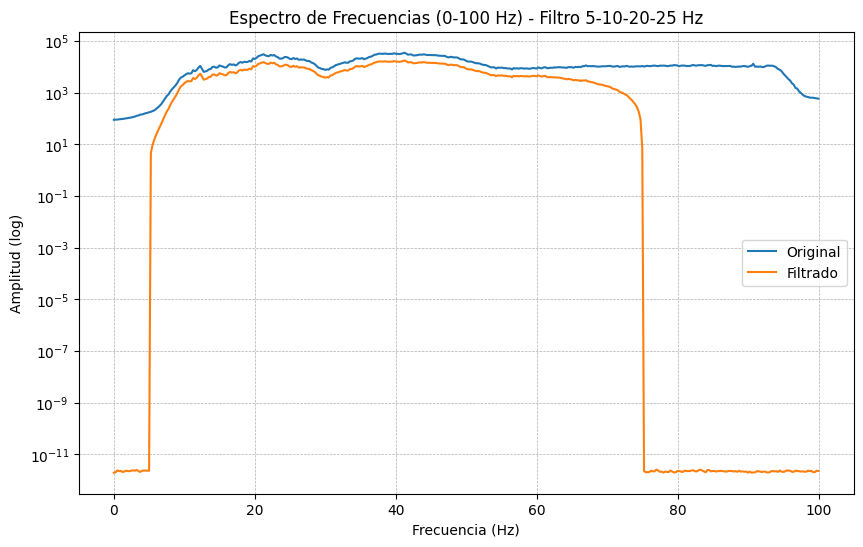

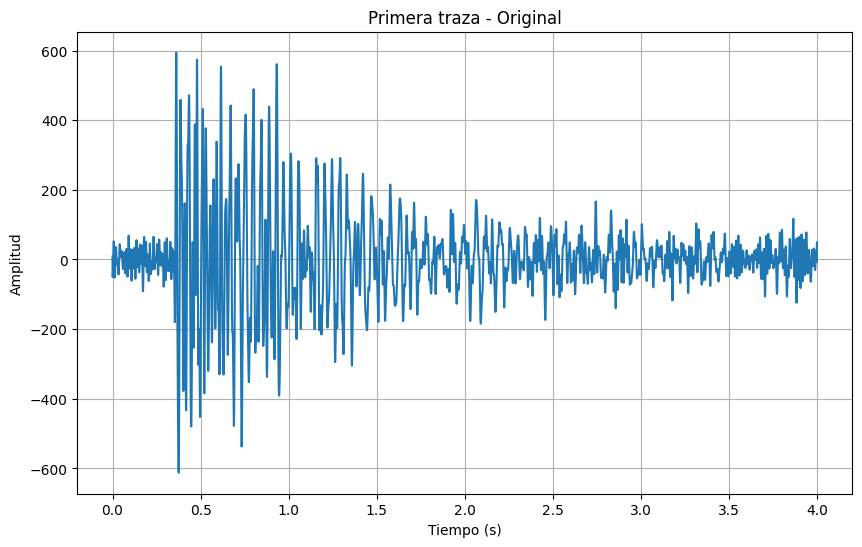

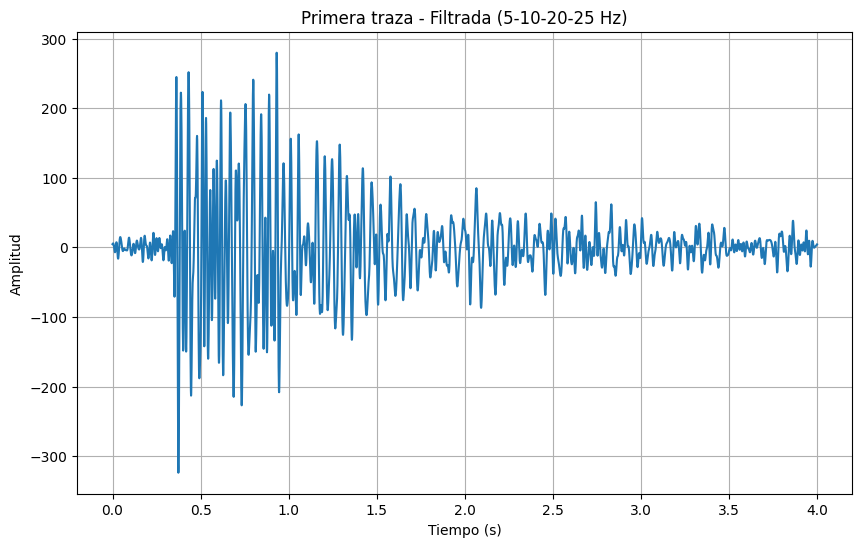

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
dt = 0.001  # Intervalo temporal (s)
f1, f2, f3, f4 = 5, 10, 60, 75  # Frecuencias de corte para el filtro trapezoidal
nt = 4001    # Número de muestras por traza
ntrazas = 308
sampling_rate = 1/dt  # 1000 Hz

# Suponemos que 'trazas' tiene la forma (308, 4001)
# trazas[i] -> una traza de longitud 4001

def trapezoidal_bandpass_filter(signal, f1, f2, f3, f4, fs):
    """
    Aplica un filtro trapezoidal en frecuencia:
    - 0 hasta f1
    - Rampa 0 a 1 entre f1-f2
    - 1 entre f2-f3
    - Rampa 1 a 0 entre f3-f4
    - 0 por encima de f4
    """
    fft_signal = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)

    # Crear la máscara del filtro
    filter_mask = np.zeros_like(freqs)

    # 0 a f1 -> 0, ya está
    # f1 a f2 -> rampa 0 a 1
    idx_f1_f2 = np.where((freqs >= f1) & (freqs <= f2))[0]
    if len(idx_f1_f2) > 0:
        filter_mask[idx_f1_f2] = (freqs[idx_f1_f2] - f1) / (f2 - f1)

    # f2 a f3 -> 1
    idx_f2_f3 = np.where((freqs > f2) & (freqs < f3))[0]
    if len(idx_f2_f3) > 0:
        filter_mask[idx_f2_f3] = 1.0

    # f3 a f4 -> rampa 1 a 0
    idx_f3_f4 = np.where((freqs >= f3) & (freqs <= f4))[0]
    if len(idx_f3_f4) > 0:
        filter_mask[idx_f3_f4] = 1.0 - (freqs[idx_f3_f4] - f3) / (f4 - f3)

    # Por encima de f4 y por debajo de f1 sigue siendo 0.

    # Aplicar el filtro a las frecuencias negativas de forma simétrica
    # Como el filtro es real y simétrico, podemos aplicar la misma máscara a frecuencias negativas.
    # (La máscara ya es simétrica porque f es simétrico al rededor de 0.)

    # Multiplicar el espectro por la máscara
    fft_filtered = fft_signal * filter_mask

    # Transformada inversa
    filtered_signal = np.fft.ifft(fft_filtered).real

    return filtered_signal

# Aplicar el filtro a todas las trazas
trazas_filtradas = np.empty((ntrazas, nt))
for i in range(ntrazas):
    trazas_filtradas[i] = trapezoidal_bandpass_filter(trazas[i], f1, f2, f3, f4, sampling_rate)

# Ahora podemos graficar el espectro promedio original y filtrado
freqs = np.fft.fftfreq(nt, dt)
fft_original = np.fft.fft(trazas, axis=1)
fft_filtrado = np.fft.fft(trazas_filtradas, axis=1)

positive_mask = (freqs >= 0) & (freqs <= 100)
positive_freqs = freqs[positive_mask]
magnitude_original = np.abs(fft_original).mean(axis=0)[positive_mask]
magnitude_filtrado = np.abs(fft_filtrado).mean(axis=0)[positive_mask]

plt.figure(figsize=(10,6))
plt.plot(positive_freqs, magnitude_original, label='Original')
plt.plot(positive_freqs, magnitude_filtrado, label='Filtrado')
plt.yscale('log')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (log)')
plt.title('Espectro de Frecuencias (0-100 Hz) - Filtro 5-10-20-25 Hz')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Graficar registro original (ej. primera traza)
plt.figure(figsize=(10,6))
plt.plot(np.arange(nt)*dt, trazas[0])
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Primera traza - Original')
plt.grid()
plt.show()

# Graficar registro filtrado (primera traza)
plt.figure(figsize=(10,6))
plt.plot(np.arange(nt)*dt, trazas_filtradas[0])
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Primera traza - Filtrada (5-10-20-25 Hz)')
plt.grid()
plt.show()


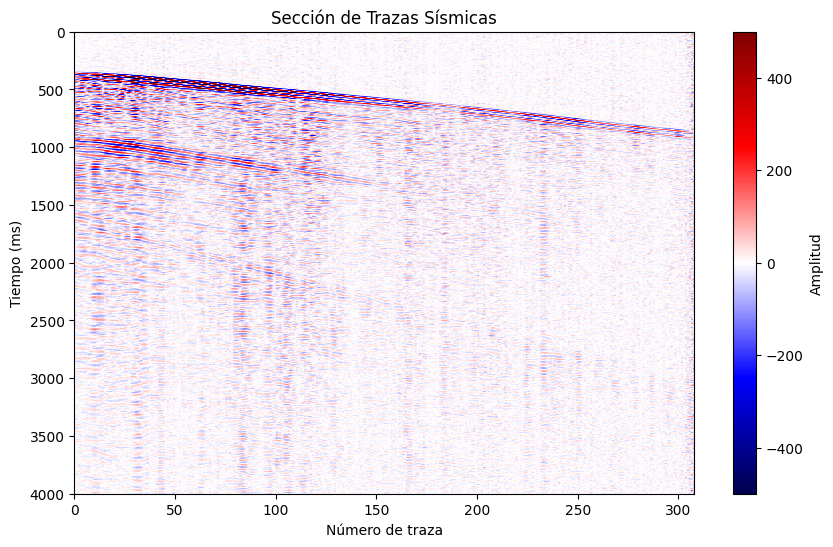

In [55]:
# Configuración para graficar las trazas sísmicas
clip = 5e+2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(trazas_filtradas.T, aspect='auto', cmap='seismic', extent=[0, 308, 4000, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

In [56]:
import numpy as np

# Parámetros
nt = 4001
nx = 308
dt = 0.001  # s
dx = 5      # m

# Escalas de frecuencias y números de onda
freqs = np.fft.fftfreq(nt, dt)          # Frecuencias en Hz
wavenumbers = np.fft.fftfreq(nx, dx)    # Números de onda en 1/m

# Transformada 2D: primero en tiempo, luego en espacio o directamente con fft2
fk_transform = np.fft.fft2(trazas.T)  # data.shape = (nt, nx)


In [57]:
f_min, f_max = 5, 100    # Hz (ejemplo)
k_min, k_max = -0.1, 0.1    # 1/m (ejemplo)

# Crear la máscara
freq_grid = freqs[:, np.newaxis]        # (nt, 1)
wavenumber_grid = wavenumbers[np.newaxis, :]  # (1, nx)

mask = (freq_grid >= f_min) & (freq_grid <= f_max) & \
       (wavenumber_grid >= k_min) & (wavenumber_grid <= k_max)

# Aplicar el filtro
fk_filtered = fk_transform * mask


In [58]:
data_filtered = np.fft.ifft2(fk_filtered).real

In [59]:
data_filtered.shape

(4001, 308)

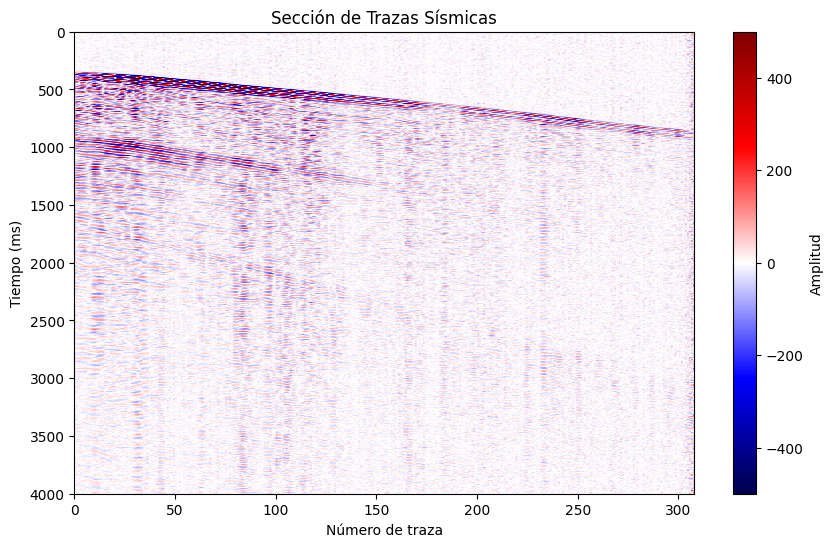

In [60]:
# Configuración para graficar las trazas sísmicas
clip = 5e+2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data_filtered, aspect='auto', cmap='seismic', extent=[0, 308, 4000, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()